In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# ls /content/drive/MyDrive/StudentCup2026/data/

description.csv  sample_submit.csv  test.csv  train.csv


In [12]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 36.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=32c1219e014711a8cc1c5b5f703a3381c9e8afeebf6742c6746cbfaa4a09e628
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

In [26]:
base_folder = "/content/drive/MyDrive/StudentCup2026/data/"
train = pd.read_csv(base_folder + "train.csv")
test = pd.read_csv(base_folder + "test.csv")

train.columns

describe = pd.read_csv(base_folder + "description.csv")
describe

,カラム名,説明
0,企業ID,企業固有のNo
1,企業名,架空の企業名
2,従業員数,連結従業員数
3,業界,製造、商社、金融、機械、アパレル、エネルギー、IT・・・等
4,上場種別,マーケット名
5,特徴,"BtoB,BtoCなど"
6,企業概要,企業の事業内容等
7,組織図,階層型組織図（フォーマットは統一されていない）
8,事業所数,企業が保有する事務所の数
9,工場数,企業が保有する工場の数


In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from sklearn.metrics import roc_auc_score


# 2. 目的変数と説明変数の分離
# ※実際のデータフレームのカラム名に合わせて '購入フラグ' や 'id' 部分を変更してください
target_col = '購入フラグ'


X = train.drop(columns=[target_col])
y = train[target_col]
X_test = test

# 3. カテゴリカル変数の処理
# LightGBMはカテゴリ変数を 'category' 型に変換することで自動的に適切に処理します
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 4. クロスバリデーションによるモデル学習・評価
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )

    # 早期打ち切り（Early Stopping）を用いた学習
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # 予測の集計
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / kf.n_splits

# 5. 精度（AUC）の確認
auc = roc_auc_score(y, oof_preds)
print(f"OOF AUC Score: {auc:.4f}")

[LightGBM] [Info] Number of positive: 143, number of negative: 450
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000551 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3750
[LightGBM] [Info] Number of data points in the train set: 593, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.241147 -> initscore=-1.146403
[LightGBM] [Info] Start training from score -1.146403
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

In [19]:
train

Index(['企業ID', '企業名', '従業員数', '業界', '上場種別', '特徴', '企業概要', '組織図', '事業所数', '工場数',
       '店舗数', '資本金', '総資産', '流動資産', '固定資産', '負債', '短期借入金', '長期借入金', '純資産',
       '自己資本', '売上', '営業利益', '経常利益', '当期純利益', '営業CF', '減価償却費', '運転資本変動',
       '投資CF', '有形固定資産変動', '無形固定資産変動(ソフトウェア関連)', 'アンケート１', 'アンケート２', 'アンケート３',
       'アンケート４', 'アンケート５', 'アンケート６', 'アンケート７', 'アンケート８', 'アンケート９', 'アンケート１０',
       'アンケート１１', '今後のDX展望', '購入フラグ'],
      dtype='object')

In [29]:
pd.set_option('display.max_columns', 100)
train.head(3)
train['上場種別'].unique()

array(['PR', 'ST', 'GR'], dtype=object)

In [119]:
from sklearn.ensemble import RandomForestClassifier
col = ['従業員数', '上場種別', '事業所数', '工場数', '店舗数', '資本金', '総資産', '流動資産', '固定資産', '負債', '短期借入金', '長期借入金', '純資産', '自己資本', '売上', '営業利益', '経常利益', '当期純利益', '営業CF', '減価償却費', '運転資本変動', '投資CF', '有形固定資産変動', '無形固定資産変動(ソフトウェア関連)', 'アンケート１', 'アンケート２', 'アンケート３', 'アンケート４', 'アンケート５', 'アンケート６', 'アンケート７', 'アンケート８', 'アンケート９', 'アンケート１０', 'アンケート１１']
X_train = train[col]
y_train = train['購入フラグ']
X_test = test[col]

mapping_dict = {
    'PR':0,
    'ST':1,
    'GR':2
}
X_train['上場種別'] = X_train['上場種別'].map(mapping_dict)
X_test['上場種別'] = X_test['上場種別'].map(mapping_dict)


model = RandomForestClassifier()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
model.score(X_train, y_train)


/tmp/ipykernel_2524/1928591411.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['上場種別'] = X_train['上場種別'].map(mapping_dict)
/tmp/ipykernel_2524/1928591411.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['上場種別'] = X_test['上場種別'].map(mapping_dict)


1.0

--- 混合行列 ---
[[563   0]
 [  0 179]]




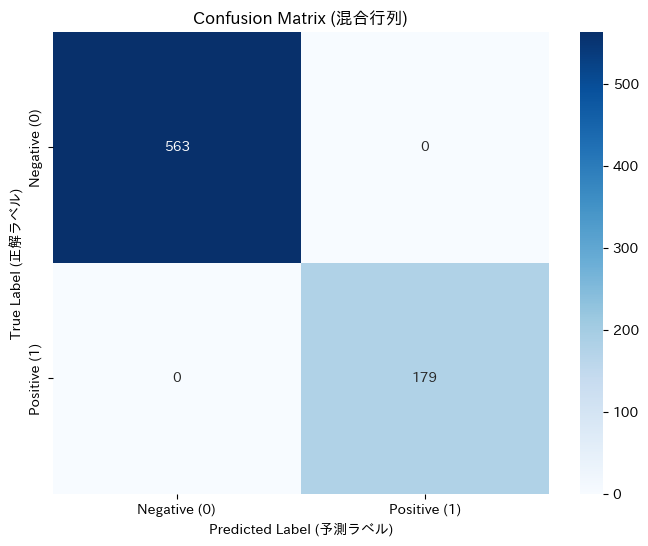

In [120]:
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_train, y_train_pred)

print("--- 混合行列 ---")
print(cm)
print("\n")


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label (予測ラベル)')
plt.ylabel('True Label (正解ラベル)')
plt.title('Confusion Matrix (混合行列)')
plt.show()

In [121]:
# 適合率 (Precision): 陽性と予測した中で、実際に陽性だった割合
precision = precision_score(y_train, y_train_pred)

# 再現率 (Recall): 実際の陽性のうち、正しく陽性と予測できた割合
recall = recall_score(y_train, y_train_pred)

# F1スコア: 適合率と再現率の調和平均
f1 = f1_score(y_train, y_train_pred)

print("--- 各種評価指標 ---")
print(f"適合率 (Precision): {precision:.4f}")
print(f"再現率 (Recall):    {recall:.4f}")
print(f"F1スコア (F1 Score): {f1:.4f}")
print("\n")

--- 各種評価指標 ---
適合率 (Precision): 1.0000
再現率 (Recall):    1.0000
F1スコア (F1 Score): 1.0000




In [122]:
sample_submit = pd.read_csv(base_folder + "sample_submit.csv", header=None)
sample_submit.iloc[:, 1] = y_test_pred
sample_submit.to_csv("submit.csv", index=False, header=False)